# Accuracy Evaluator Tool



### Introduction
The Accuracy evaluator is a framework to define and execute the end to end accuracy evaluation of a given model. The evaluation pipeline is configured in a yaml config file for a model and the tool loads this config file to execute the pipeline.

The Pipeline consists of the below stages. The tool has options to run the complete pipeline or parts of it.
- **Selecting a Dataset** (Orginal Dataset/ **Preprocessed dataset, calibration dataset)**
- Running Preprocessors on the dataset *(Optional)*
- **Running inference on the processed data on one or more platforms (eg. ONNXRT, FP16 on AIC, INT8 on AIC, etc).**
- Post processing of inference raw outputs *(Optional)*
- Accuracy Metrics evaluation *(Optional)*

Following are the Key Features of Accuracy Evaluator Tool:
- The Tool can do a PGQ Sweep to identify the best PGQ parameters while executing in INT8 precision on AIC platform
- The entire pipeline is divided into multiple stages and tool can start and end at any stage. The valid pipeline stages are "preproc", "compiled", "infer", "postproc", "metric".

Following is the brief description of each pipeline stage:

**Preproc:** This stage can preprocess the input data and store in a folder, so that the next runs can skip this stage. The tool provides various preprossing plugins like resize, crop, normalize, gpt2_tokenizer, filter_dataset, etc. Users can create custom pre-processing plugins as well.

**Compiled:** This stage compiles the model for all the platforms configured in the model_config.yaml file. The Platforms can be FP16, INT8 with various PGQ parameters etc. All the compiled .bin QPC files are stored in a folder so that users dont have to compile the model for all the variations every time the tool is used.

**infer:** This stage uses the preprocessed data to infer using all the compiled QPC files generated in the "Compiled" stage. The outputs can be stored in a folder.

**postproc:** At this stage the infered data is post processed. Users can either create custom postprocessing plugins or use the builtin post processing plugins like object_detection, qaic_smart_nms, squad_postprocess, centerface_postproc, etc.

**metric:** The model can be evaluated using custom plugins or inbuilt plugins like top-k, map_coco , map_voc, etc.

In this notebook, we will show the steps to be followed to compare and show accuracy(model outputs comparison) of Resnet50 model across Qualcomm AI 100 Device and ONNX runtime, using a preprocessed dataset.
We compare and show accuracy(model outputs comparison) across different precisions and Quantization schemes on AI100 device for evaluation. 


In [1]:
!/opt/qti-aic/dev/python/qaic-env/bin/python -m pip install ipykernel 
!source /opt/qti-aic/dev/python/qaic-env/bin/activate

Badly placed ()'s.


In [2]:
import sys
assert sys.executable  == '/opt/qti-aic/dev/python/qaic-env/bin/python'
!/opt/qti-aic/tools/qaic-version-util
!{sys.executable} --version

platform:AIC.1.10.0.183
apps:AIC.1.10.0.183
factory:not found
Python 3.8.10


Following is the model config file used

In [1]:
!cat bert_base.yaml

## 1.  Starting and Ending at Different Pipeline Stages:

**Valid Pipeline Stages** : "preproc", "compiled", "infer", "postproc", "metric"


1.1. **Perform Preprocessing only**

User can use evaluator tool to only perform preprocessing of the dataset. This can be used for saving the preprocessing overhead for each evaluation while using the dataset.


In [5]:
model_config_path = "bert_base.yaml"


In [5]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config 'bert_base.yaml' -device-id 0 -pipeline-end preproc \
        -onnx-symbol sequence_length:128 \
        -work-dir preproc_only 

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 26.54it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1352.83it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1349706.01it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 927943.36it/s]
INFO: Executing Preprocessors for calibration inputs
INFO: Executing Preprocessors
INFO: qacc pipeline ended successfully


1.2 **Reuse Preprocessed Data and Start from Inference Stage**

User can use evaluator tool to use existing preprocessed dataset for evaluating models. The flag "-pipeline-start" is set to infer accordingly 

In [4]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 0 -pipeline-start infer \
        -preproc-file preproc_only/preproc/processed-outputs.txt \
        -onnx-symbol sequence_length:128 \
        -debug \
        -calib-file preproc_only/calibration/processed-outputs.txt 

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 25.99it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1342.12it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1340361.39it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 964207.82it/s]
INFO: Using devices: [0] for evaluation
INFO: Total platform configurations: 104
INFO: Total inputs for execution: 18498 and calibration: 177
INFO: Approximate disk usage  - 1.89 GB
INFO: C

INFO: Completed compilation for plat13_aic took: 135.1254267692566 seconds
INFO: Starting compilation for plat18_aic
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connection: huggingface.co
DEBUG: https://huggingface.co:443 "GET /api/models/madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1 HTTP/1.1" 200 7479
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/vocab.txt HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/added_tokens.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/

DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
INFO: Completed compilation for plat26_aic took: 180.42420315742493 seconds
INFO: Starting compilation for plat36_aic
DEBUG: Running total of 100 workers for platform : plat29_aic
INFO: Starting Inference for: plat29_aic
INFO: Completed compilation for plat25_aic took: 192.82760953903198 seconds
INFO: Starting compilation for plat37_aic
INFO: Completed compilation for plat28_aic took: 179.87108540534973 se

INFO: Completed compilation for plat51_aic took: 131.2954545021057 seconds
INFO: Starting compilation for plat56_aic
INFO: Completed compilation for plat50_aic took: 151.76707673072815 seconds
INFO: Starting compilation for plat57_aic
INFO: Completed compilation for plat49_aic took: 172.26102375984192 seconds
INFO: Starting compilation for plat58_aic
INFO: Completed compilation for plat48_aic took: 174.73799228668213 seconds
INFO: Starting compilation for plat59_aic
INFO: Completed compilation for plat54_aic took: 116.8149163722992 seconds
INFO: Starting compilation for plat60_aic
INFO: Completed compilation for plat52_aic took: 187.63122057914734 seconds
INFO: Starting compilation for plat61_aic
INFO: Metrics for plat32_aic : {'f1': 79.331757, 'exact': 70.548723, 'total': 10570}
INFO: Completed Inference for : plat32_aic
DEBUG: plat41_aic will be executed on device: 0
INFO: Executing plat41_aic on AIC device: 0
DEBUG: DataReader complete plat41_aic
DEBUG: Starting new HTTPS connection

DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connection: huggingface.co
DEBUG: https://huggingface.co:443 "GET /api/models/madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1 HTTP/1.1" 200 7479
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/vocab.txt HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/added_tokens.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/special_tokens_map.json HTTP/1.1" 200 0
D

...

DEBUG: Running total of 100 workers for platform : plat24_aic
INFO: Starting Inference for: plat24_aic
DEBUG: Clearing the InfereneSet objects for plat24_aic
DEBUG: Invoking Metric.finalize() for plat24_aic --> <qaic_pytools.qacc.plugin.squad_eval object at 0x7fe677594c10>
INFO: Metrics for plat24_aic : {'f1': 76.660792, 'exact': 67.767266, 'total': 10570}
INFO: Completed Inference for : plat24_aic
DEBUG: plat42_aic will be executed on device: 0
INFO: Executing plat42_aic on AIC device: 0
DEBUG: DataReader complete plat42_aic
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connect

DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connection: huggingface.co
DEBUG: https://huggingface.co:443 "GET /api/models/madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1 HTTP/1.1" 200 7479
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/vocab.txt HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/added_tokens.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/special_tokens_map.json HTTP/1.1" 200 0
D

DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/special_tokens_map.json HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Running total of 100 workers for platform : plat8_aic
INFO: Starting Inference for: plat8_aic
DEBUG: Clearing the InfereneSet objects for plat8_aic
DEBUG: Invoking Metric.finali

DEBUG: Running total of 100 workers for platform : plat33_aic
INFO: Starting Inference for: plat33_aic
DEBUG: Clearing the InfereneSet objects for plat33_aic
DEBUG: Invoking Metric.finalize() for plat33_aic --> <qaic_pytools.qacc.plugin.squad_eval object at 0x7fe70fb72d60>
INFO: Metrics for plat33_aic : {'f1': 35.116175, 'exact': 20.671712, 'total': 10570}
INFO: Completed Inference for : plat33_aic
DEBUG: plat73_aic will be executed on device: 0
INFO: Executing plat73_aic on AIC device: 0
DEBUG: DataReader complete plat73_aic
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connect

DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/config.json HTTP/1.1" 200 0
DEBUG: Resetting dropped connection: huggingface.co
DEBUG: https://huggingface.co:443 "GET /api/models/madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1 HTTP/1.1" 200 7479
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/vocab.txt HTTP/1.1" 200 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/added_tokens.json HTTP/1.1" 404 0
DEBUG: Starting new HTTPS connection (1): huggingface.co:443
DEBUG: https://huggingface.co:443 "HEAD /madlag/bert-base-uncased-squadv1-x2.01-f89.2-d30-hybrid-rewind-opt-v1/resolve/main/special_tokens_map.json HTTP/1.1" 200 0
D

1.3. **Using Accuracy Evaluator till Compilation**:

Model compilation happens on Host(x86) machine, user has the flexiblity to compile the model on machine which doesnt have AIC100 card and then transfer the work directory (compiled binaries, processed inputs) to a machine having AIC100 card to perform evaluation. The flag "-pipeline-end" is set accordingly.

In [6]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 0 -pipeline-end compiled \
        -platform-tag aic_fp16 -work-dir experiment_1

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 26.50it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1357.51it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1338782.83it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 919803.51it/s]
INFO: Using devices: [0] for evaluation
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Clea

## 2. Execute Specific Platform based on tag

The platforms to execute can be grouped based on tags in the model config yaml file ( in this case). 

For example, in bert_base.yaml we configured the tag "pgq_sweep" is used to group various combinations of INT8 precision and Quantization parameters.

In the below command, "-platform-tag=aic_fp16" is used to execute with only the fp16 precision. 

In [7]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 0  \
        -platform-tag=aic_fp16 -silent

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 26.59it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1340.35it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1311262.74it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 957603.65it/s]
INFO: Using devices: [0] for evaluation
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Clea

## 3. Update Platform parameters based on tag dynamically while invoking

The execution parameters can be changed dynamycally. In the below flag  -platform-tag-params "aic_fp16,aic-num-cores:4" is used to change the aic-num-cores parameters dynamically. The paramter used in the CLI will overwrite the configuration in the model config file.

In [9]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path}  -device-id 0 \
        -platform-tag=aic_fp16 -platform-tag-params "aic_fp16,aic-num-cores:4" # "-platform-tag-params tag,param1:value1;param2:value2"

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 26.61it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1338.21it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1330745.71it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 923855.51it/s]
INFO: Using devices: [0] for evaluation
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Clea

## 4. Measuring Performance Scores (Throughput and Latency)

The evaluator tool can identify the Throughput and Latency for the model by running multiple iterations as configured in flag "-perf-iter-count"

In [10]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path}  -device-id 0 -platform-tag=aic_fp16 \
        -enable-perf -perf-iter-count 100

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Using Memory Pipeline for accuracy evaluation
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:01<00:00, 26.37it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:07<00:00, 1348.38it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 1304702.57it/
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 871996.67it/s]
INFO: Using devices: [0] for evaluation
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Clea

## 5. Using Comparators 

Comparator is useful feature when multiple configurations are provided and the user wants to find the inputs for which the maximum gap is observed with respect to the reference platform. Comparator is enabled by default and the tool supports various set of in built comparators.By default, average comparator is used.

The comparator option takes the fields below and lists the preprocessed inputs that caused top mismatches in model outputs (regarding the reference) amongst the complete input list.

- **type**: One of inbuilt comparator types (avg | abs| l1norm | l2norm | rme) or custom comparator. See below for using Custom Comparators.
- **tol**: Tolerance value - depends on per comparator described below:
    - *'abs'* - absolute % difference. Example: 0.01 means that a 1% difference in the absolute tensor values from the reference is marked as a mismatch.
    - For all other inbuilt comparators - this defines the number of decimal places to round to before evaluating the comparator.
- **fetch_top**: Out of all mismatched files, order by maximum % mismatch and write the fetch_top number of preprocessed input file paths in a file (<plat_name>_mm.txt) per platform. Default value: 1
- **enabled**: By default, enabled (True)

#### Example 

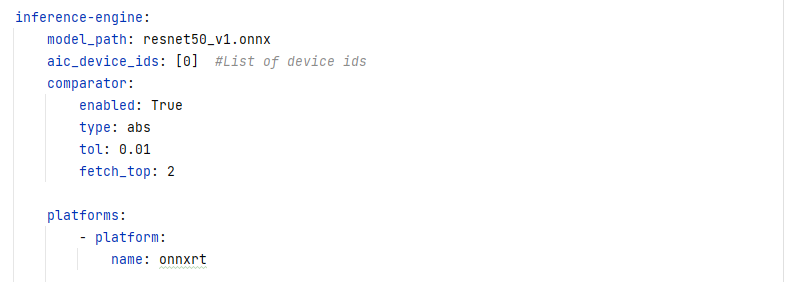


### 5.1 Using Built in Comparators

##### List of comparators supported:

- *AvgComparator* : **'avg'**                     --> comparison using Average error
- *TolComparator* : **'abs'**                     --> comparison using given tolerance value
- *NormComparato* : **'l1norm'** or **'l2norm'**  --> comparison using using L1_norm/L2_norm
- *RMEComparator* : **'rme'**                     --> comparison using root mean square error
- *KLDComparator* : **'kld'**                     --> comparison using KL Divergence
- *StdComparator* : **'std'**                     --> comparison using % difference in standard deviation
- *CosComparator* : **'cos'**                     --> comparison using Cosine Similarity 


### 5.2 Using Custom Comparators

Users can configure one or more custom defined comparators. Custom comparators are defined in a Python class extending the qaic_pytools.common.Comparators class and implementing a single compare method.
- **The custom comparator Python files are copied inside the directory configured in defaults.yaml configuration field common.custom_comparators_path.**
- There could be more than one comparator class defined in same Python file.
- Once created, the string returned by name() can be used as the comparator name like any other inbuilt comparators.

#### Comparator Class Interface:
```
class Comparators(ABC):
    """
    Comparators is an abstract class that compares two values using specific comparator type
    """

    def compare(self, op1, op2):
        """
        This method compares two numpy arrays with specific comparator type.
        Args:
            op1 : numpy array 1
            op2 : numpy array 2 
        Returns:
            match_percent : percentage of match between op1 and op2
        """
        pass

    def name(self):
        """
        Return a unique name of the comparator (without spaces)
        """
        return ''

    def display_name(self):
        """
        Returns the name to be displated on the comparison table.
        """
        return ''
```



#### Example 

In [11]:
import os 
import qaic_pytools.common.defaults as df
defaults = df.Defaults.getInstance()
custom_path = defaults.get_value("common.custom_comparators_path")
os.makedirs(custom_path,exist_ok=True)

In [12]:
%%writefile /opt/qti-aic/tools/qaic-pytools/custom_comparators/mycomp.py

from qaic_pytools.common.comparators import Comparators

class XYZ_cmp(Comparators):
    def __init__(self, tol=1e-5):
        # tol holds the tolerance threshold value passed by user.
        # to be used accordingly by the comparison logic.
        self._tol = tol
  
    def display_name(self): 
        # A string used to show the Column name in the final report. 
        return 'xyz(%)' 
    def compare(self, op1, op2): 
        # write compare logic 
        # op1 and op2 are two flattened numpy tensor outputs for the layer 
        # return percent match (0 -> 100) 
        # match_info string to give details on the mismatch or for edge cases. 
        return 100.0, match_info 


Writing /opt/qti-aic/tools/qaic-pytools/custom_comparators/mycomp.py
